In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
pd.set_option('display.max_columns',None)
import warnings
warnings.filterwarnings('ignore')

In [2]:
train_labels = pd.read_csv('train_labels.csv') # it has two column (building_id & damage_grade) 
train_values = pd.read_csv('train_values.csv') # it has many column (buidling_id & and others)


In [3]:
display(train_labels.shape)
display(train_values.shape)

(260601, 2)

(260601, 39)

In [4]:
display(train_labels.info())
print('==================')
display(train_values.info())

<class 'pandas.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   building_id   260601 non-null  int64
 1   damage_grade  260601 non-null  int64
dtypes: int64(2)
memory usage: 4.0 MB


None

<class 'pandas.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 39 columns):
 #   Column                                  Non-Null Count   Dtype
---  ------                                  --------------   -----
 0   building_id                             260601 non-null  int64
 1   geo_level_1_id                          260601 non-null  int64
 2   geo_level_2_id                          260601 non-null  int64
 3   geo_level_3_id                          260601 non-null  int64
 4   count_floors_pre_eq                     260601 non-null  int64
 5   age                                     260601 non-null  int64
 6   area_percentage                         260601 non-null  int64
 7   height_percentage                       260601 non-null  int64
 8   land_surface_condition                  260601 non-null  str  
 9   foundation_type                         260601 non-null  str  
 10  roof_type                               260601 non-null  str  
 11  ground_floo

None

In [5]:
# display(pd.merge(train_labels, train_values , on='building_id' ,how = 'inner').info())

df = pd.merge(train_labels, train_values , on='building_id' ,how = 'inner')


In [6]:
df.shape

(260601, 40)

In [7]:
df.head(5)

,building_id,damage_grade,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,legal_ownership_status,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,802906,3,6,487,12198,2,30,6,5,t,r,n,f,q,t,d,1,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0
1,28830,2,8,900,2812,2,10,8,7,o,r,n,x,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0
2,94947,3,21,363,8973,2,10,5,5,t,r,n,f,x,t,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0
3,590882,2,22,418,10694,2,10,6,5,t,r,n,f,x,s,d,0,1,0,0,0,0,1,1,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0
4,201944,3,11,131,1488,3,30,8,9,t,r,n,f,x,s,d,1,0,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0


In [8]:
df.dtypes

building_id                               int64
damage_grade                              int64
geo_level_1_id                            int64
geo_level_2_id                            int64
geo_level_3_id                            int64
count_floors_pre_eq                       int64
age                                       int64
area_percentage                           int64
height_percentage                         int64
land_surface_condition                      str
foundation_type                             str
roof_type                                   str
ground_floor_type                           str
other_floor_type                            str
position                                    str
plan_configuration                          str
has_superstructure_adobe_mud              int64
has_superstructure_mud_mortar_stone       int64
has_superstructure_stone_flag             int64
has_superstructure_cement_mortar_stone    int64
has_superstructure_mud_mortar_brick     

### Statistics - ALL

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
building_id,260601.0,525675.482773,304544.999032,4.0,261190.0,525757.0,789762.0,1052934.0
damage_grade,260601.0,2.238272,0.611814,1.0,2.0,2.0,3.0,3.0
geo_level_1_id,260601.0,13.900353,8.033617,0.0,7.0,12.0,21.0,30.0
geo_level_2_id,260601.0,701.074685,412.710734,0.0,350.0,702.0,1050.0,1427.0
geo_level_3_id,260601.0,6257.876148,3646.369645,0.0,3073.0,6270.0,9412.0,12567.0
count_floors_pre_eq,260601.0,2.129723,0.727665,1.0,2.0,2.0,2.0,9.0
age,260601.0,26.535029,73.565937,0.0,10.0,15.0,30.0,995.0
area_percentage,260601.0,8.018051,4.392231,1.0,5.0,7.0,9.0,100.0
height_percentage,260601.0,5.434365,1.918418,2.0,4.0,5.0,6.0,32.0
has_superstructure_adobe_mud,260601.0,0.088645,0.284231,0.0,0.0,0.0,0.0,1.0


### Statistics - Categorical Columns

In [10]:
df.describe(include = 'object').T

,count,unique,top,freq
land_surface_condition,260601,3,t,216757
foundation_type,260601,5,r,219196
roof_type,260601,3,n,182842
ground_floor_type,260601,5,f,209619
other_floor_type,260601,4,q,165282
position,260601,4,s,202090
plan_configuration,260601,10,d,250072
legal_ownership_status,260601,4,v,250939


In [11]:
df.isnull().sum().sum()

np.int64(0)

There is no missing value

In [12]:
df.duplicated().sum()

np.int64(0)

### THere is no duplicate in the data

In [13]:
df.damage_grade.value_counts().sort_index()

damage_grade
1     25124
2    148259
3     87218
Name: count, dtype: int64

In [14]:
df.age.sort_values().unique()

array([  0,   5,  10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,
        65,  70,  75,  80,  85,  90,  95, 100, 105, 110, 115, 120, 125,
       130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190,
       195, 200, 995])

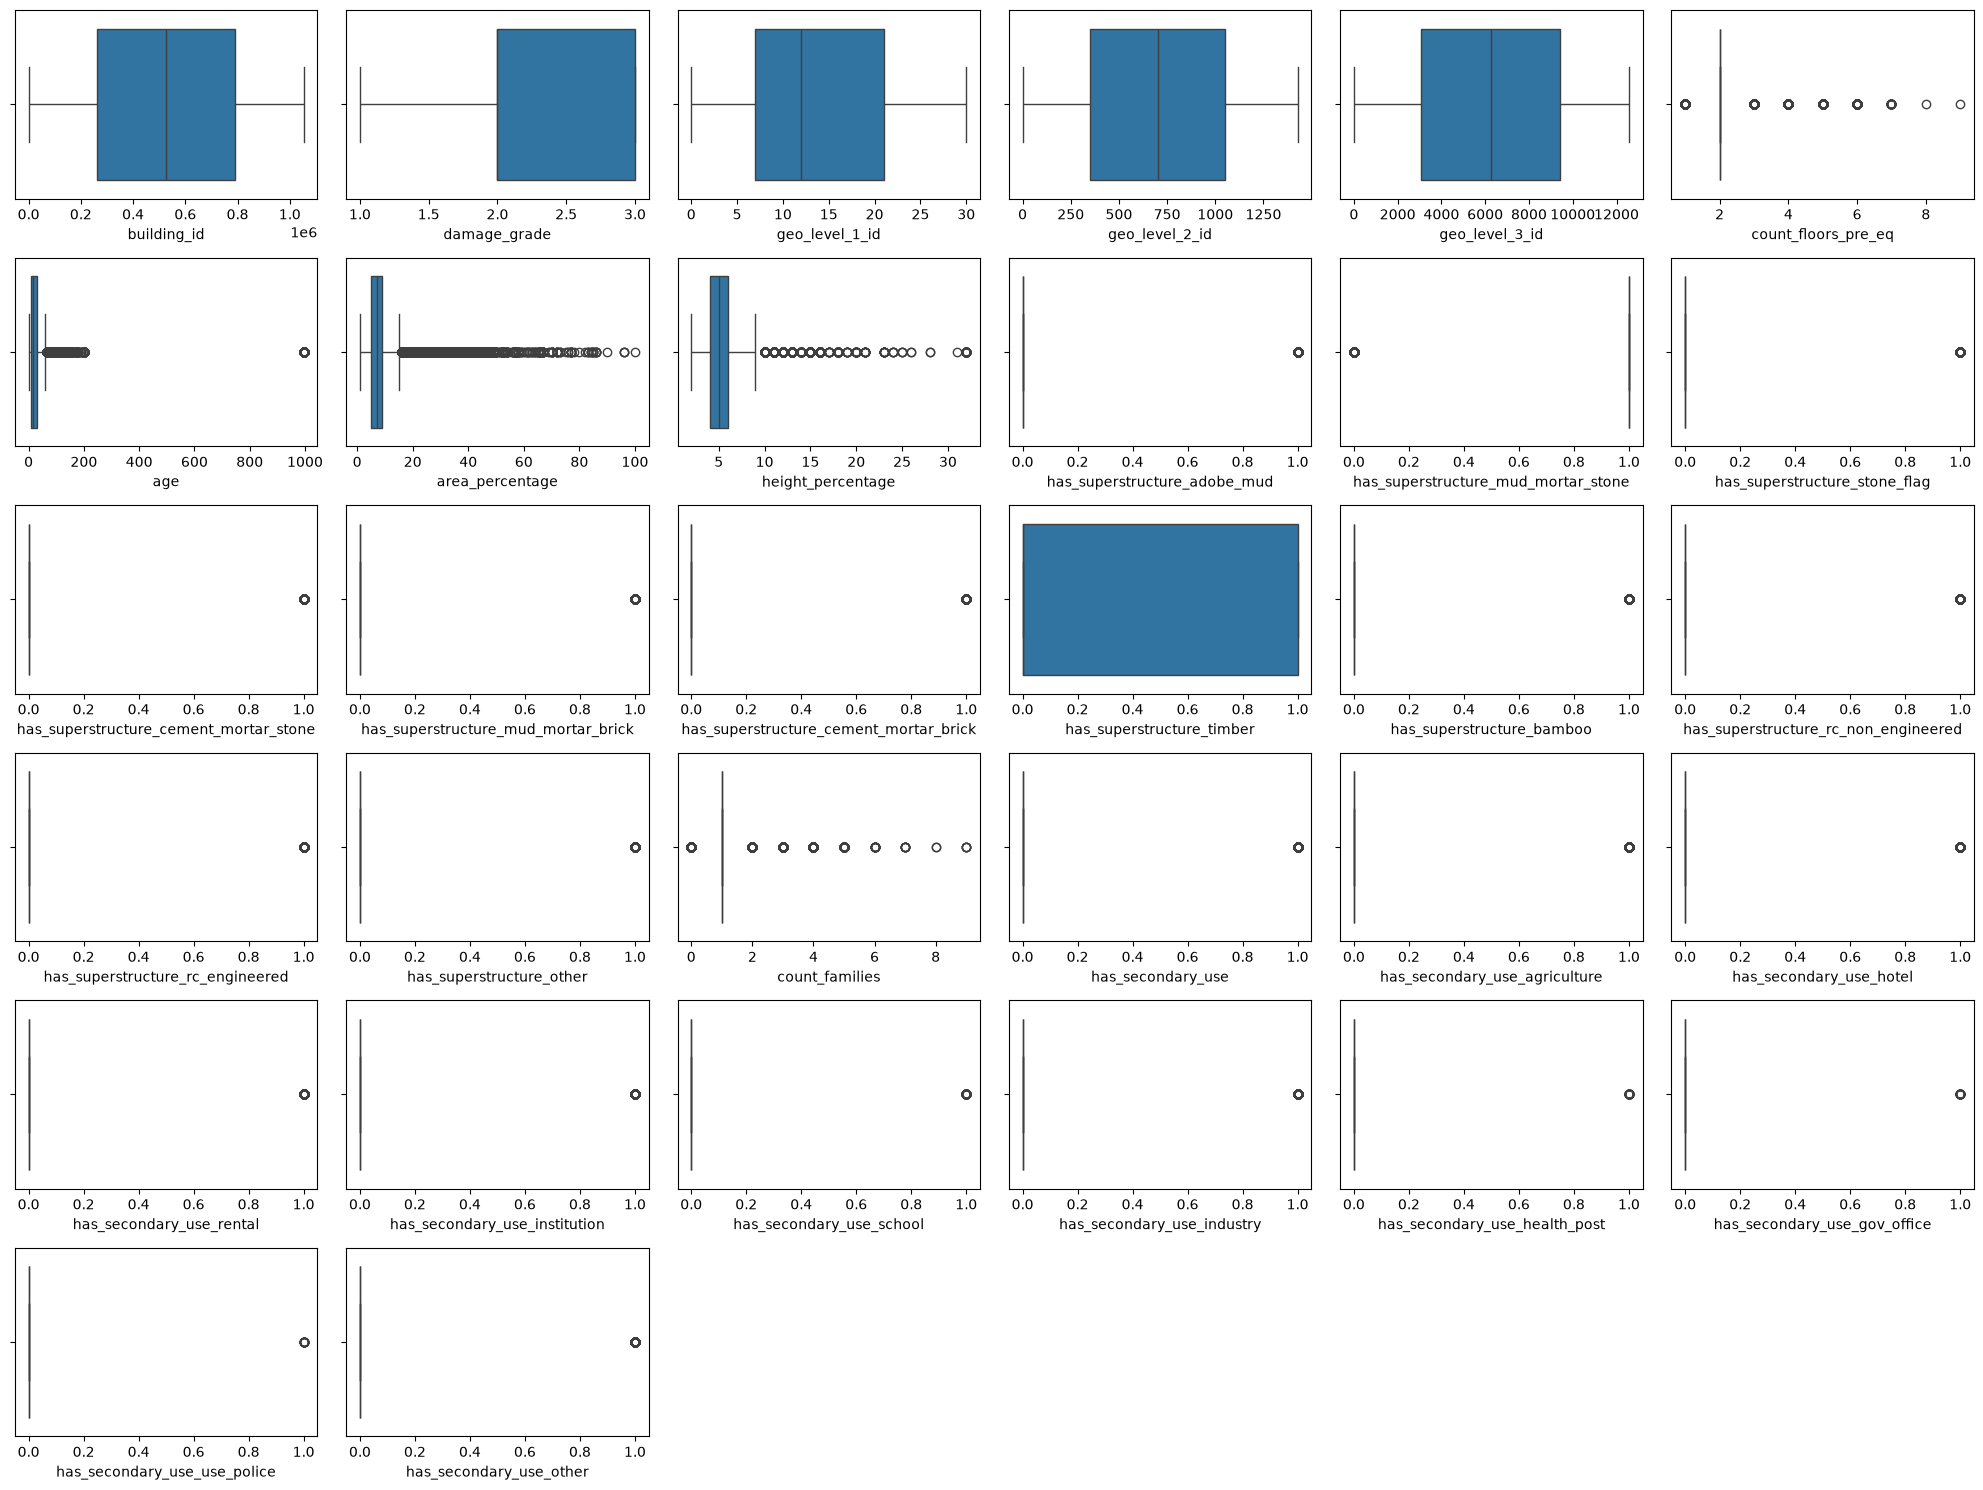

In [15]:
import seaborn as sns

plt.figure(figsize=(20,15))

numeric_cols = df.select_dtypes(include = np.number)
# print(numeric_cols.columns)
for i, col in enumerate(numeric_cols.columns):
    plt.subplot(6, 6, i+1)
    sns.boxplot(x = df[col])

plt.tight_layout()
plt.show()

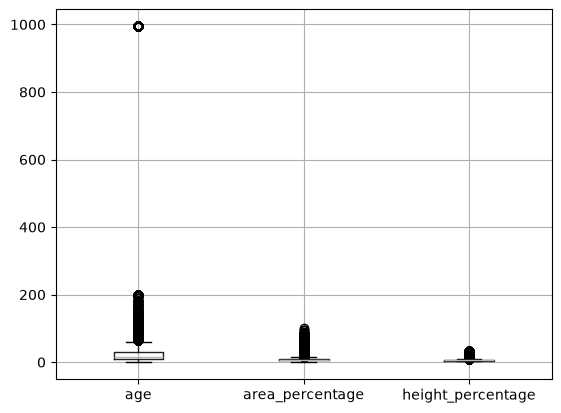

In [16]:
df.boxplot(column=['age','area_percentage','height_percentage'])
plt.show()

In [17]:
(df['age']== 995).sum()

np.int64(1390)

In [18]:
(df['age'] == 995).sum()




np.int64(1390)

In [19]:
normal_age_median = df[df['age'] != 995]['age'].median()

In [20]:
df['age'] = df['age'].replace(995, normal_age_median)

display(df['age'].max())

200

### age of any place can be upto 200 

---------------

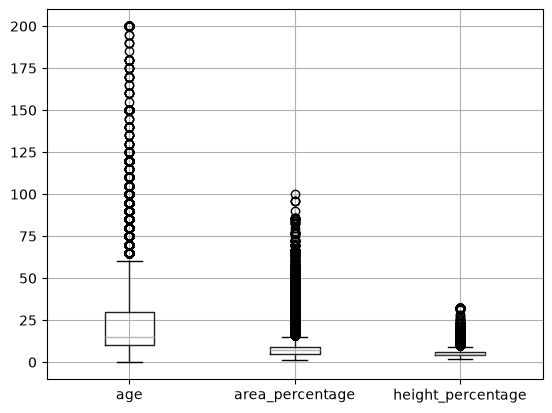

In [21]:
df.boxplot(column=['age','area_percentage','height_percentage'])
plt.show()

### capping 'area_percentage' and 'height_percentage'

In [22]:
df[col].unique().sum()

np.int64(1)

In [23]:
for col in ['area_percentage', 'height_percentage']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3- Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    num_outlier = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f'{col} : capping {num_outlier} outlier to range [{lower_bound:.2f}, {upper_bound:.2f}]')
    df[col] = df[col].clip(lower=lower_bound, upper= upper_bound)

area_percentage : capping 13557 outlier to range [-1.00, 15.00]
height_percentage : capping 7843 outlier to range [1.00, 9.00]


In [24]:
df.select_dtypes(exclude = np.number).columns

Index(['land_surface_condition', 'foundation_type', 'roof_type',
       'ground_floor_type', 'other_floor_type', 'position',
       'plan_configuration', 'legal_ownership_status'],
      dtype='str')

### Categorical Columns

In [25]:
categorical_columns = df.select_dtypes(exclude = np.number).columns


    

## Target 

In [26]:
df['damage_grade'] = df['damage_grade'].astype(int)

In [27]:
# print(df.dtypes)

## EDA

#### Univariate Analysis

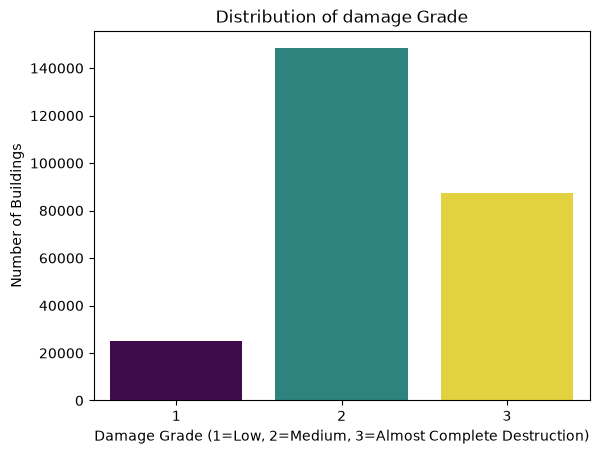

In [28]:
# Damage grade distribution (target)

sns.countplot(data = df, x = 'damage_grade', palette='viridis', hue= 'damage_grade', legend = False)
plt.title('Distribution of damage Grade')
plt.xlabel('Damage Grade (1=Low, 2=Medium, 3=Almost Complete Destruction)')
plt.ylabel('Number of Buildings')
plt.show()

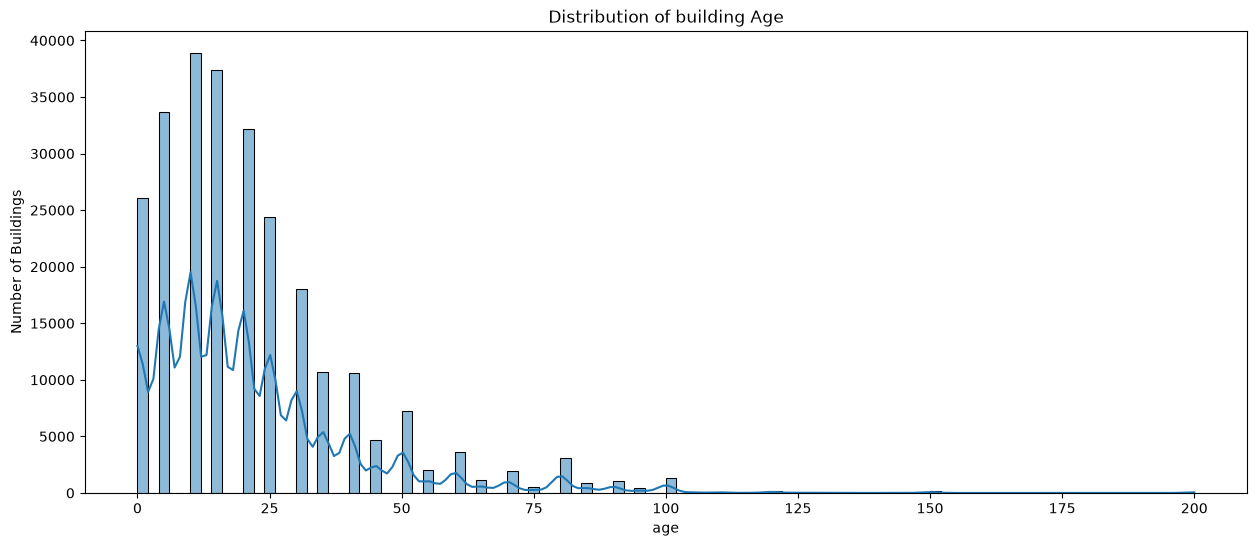

In [29]:
# Distribution of building age
plt.figure(figsize=(15,6))
sns.histplot(data = df, x = 'age', bins = 100,kde = True)
plt.title('Distribution of building Age')
plt.xlabel('age')
plt.ylabel('Number of Buildings')

plt.show()

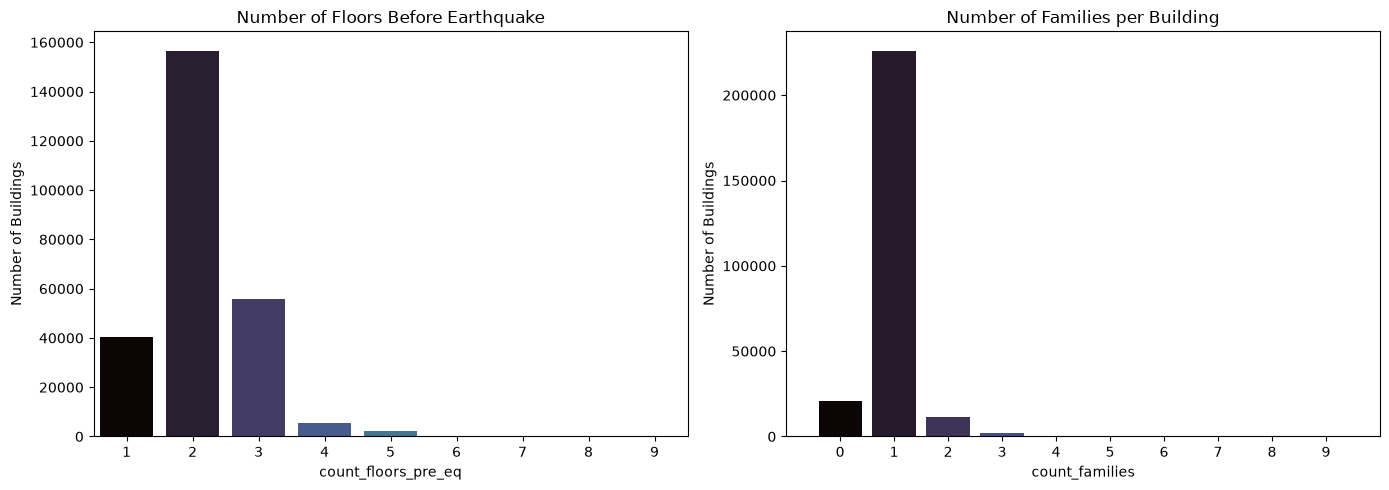

In [30]:
# Distribution of number of floors and count of families
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.countplot(x="count_floors_pre_eq", data=df, ax=axes[0], palette="mako", hue="count_floors_pre_eq", legend=False)
axes[0].set_title("Number of Floors Before Earthquake")
axes[0].set_ylabel('Number of Buildings')




sns.countplot(x="count_families", data=df, ax=axes[1], palette="mako", hue="count_families", legend=False)
axes[1].set_title("Number of Families per Building")
axes[1].set_xlim(-1, 10)  # limit view to common range
axes[1].set_ylabel('Number of Buildings')


plt.tight_layout()
plt.show()

### Bivariate Analysis - structural feature vs damage

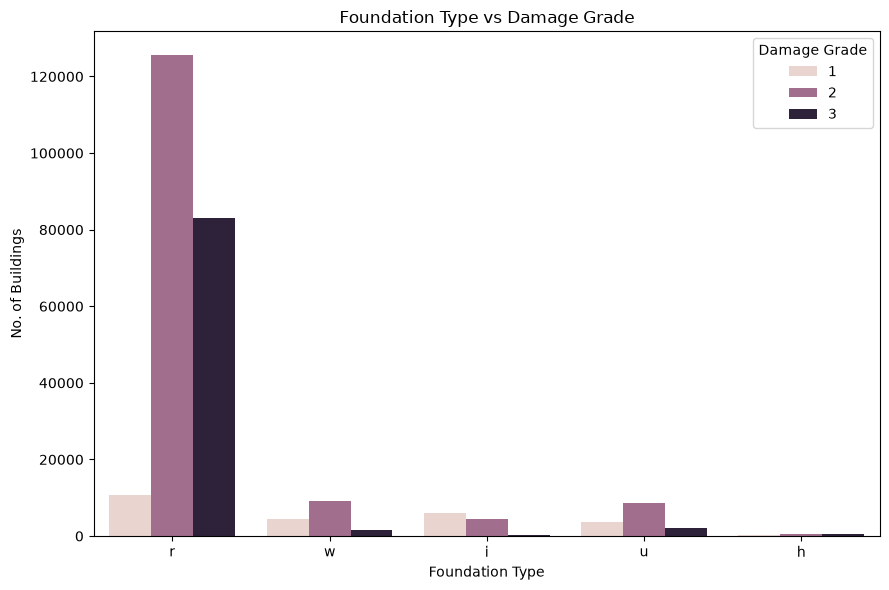

In [31]:
# Foundation Type vs Damage Grade

plt.figure(figsize=(9,6))

sns.countplot(data=df, x = 'foundation_type', hue='damage_grade')
plt.title('Foundation Type vs Damage Grade')
plt.xlabel('Foundation Type')
plt.ylabel('No. of Buildings')
plt.legend(title = 'Damage Grade')

plt.tight_layout()
plt.show()

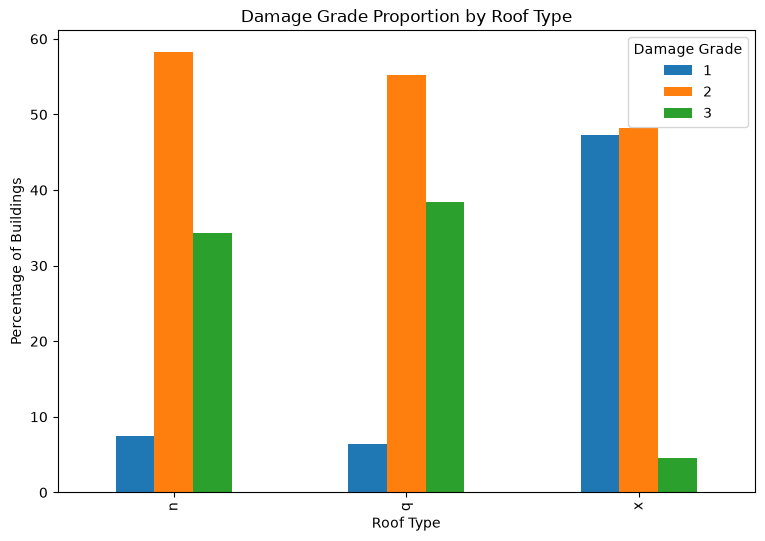

In [32]:
#Roof Type vs damage grade
# Roof type vs damage grade (proportion within each roof type, more interpretable than raw counts)
roof_damage_pct = pd.crosstab(df["roof_type"], df["damage_grade"], normalize="index") * 100
roof_damage_pct.plot(kind="bar", figsize=(9, 6))
plt.title("Damage Grade Proportion by Roof Type")
plt.ylabel("Percentage of Buildings")
plt.xlabel("Roof Type")
plt.legend(title="Damage Grade")
plt.show()

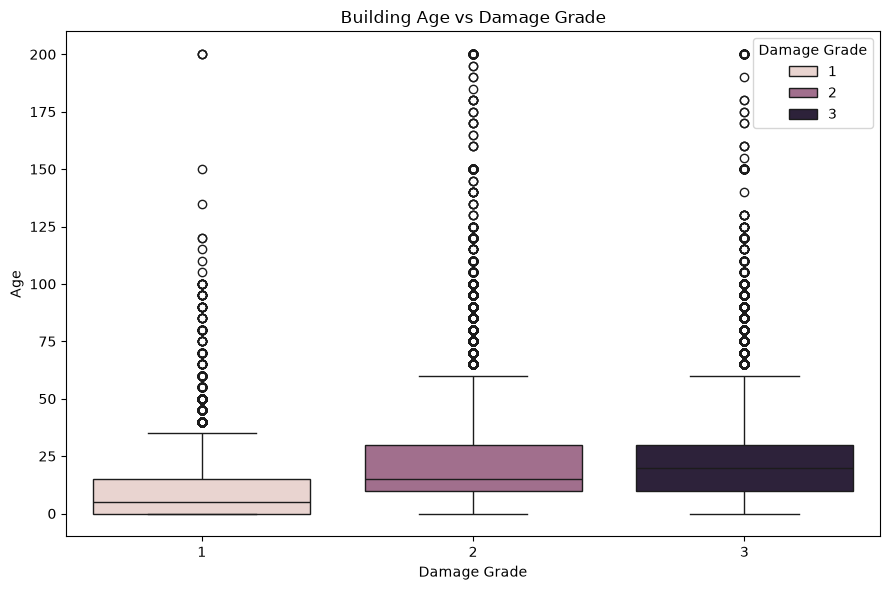

In [33]:
# building age vs damage age

plt.figure(figsize=(9,6))

sns.boxplot(data=df, y = 'age', x='damage_grade', hue = 'damage_grade')
plt.title('Building Age vs Damage Grade')

plt.ylabel('Age')
plt.xlabel('Damage Grade')
plt.legend(title = 'Damage Grade')
plt.tight_layout()
plt.show()

In [34]:
# d

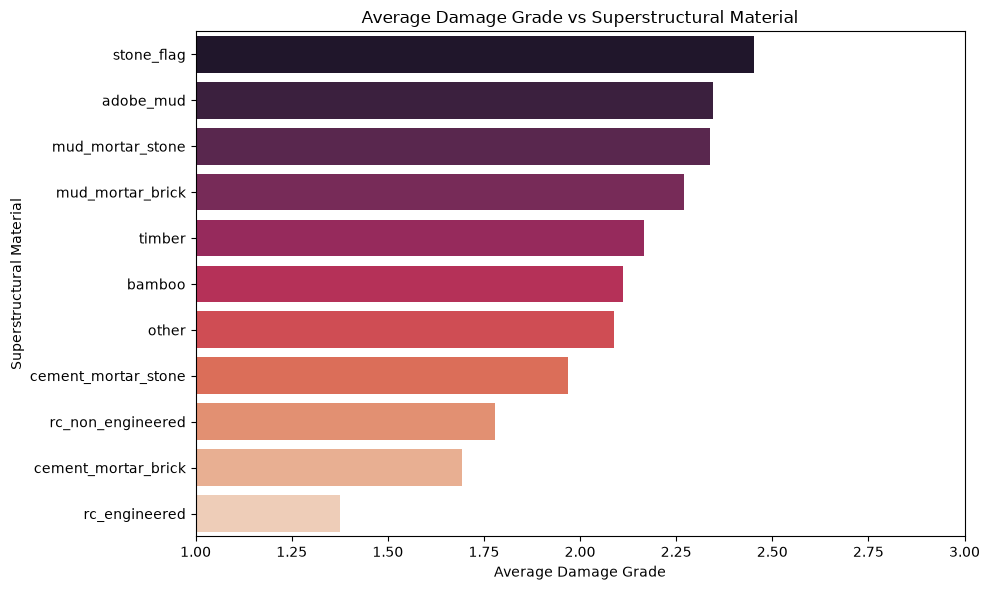

In [35]:
superstructure_cols  =[c for c in df.columns if c.startswith('has_superstructure_')]
# display(superstructure_cols)

avg_damage_by_material = []

for col in superstructure_cols:
    avg_damage_mean = df.loc[df[col] == 1, 'damage_grade'].mean()
    avg_damage_by_material.append((col.replace('has_superstructure_', ''), avg_damage_mean))

# making new column to draw plot with different material
material_df = pd.DataFrame(avg_damage_by_material, columns = ['material', 'avg_damage_grade'])
material_df = material_df.sort_values('avg_damage_grade', ascending =False)

# ploting new material columns
plt.figure(figsize=(10,6))
sns.barplot(data=material_df, x = 'avg_damage_grade', y ='material',hue = 'material' ,palette='rocket')

plt.title('Average Damage Grade vs Superstructural Material')
plt.xlabel('Average Damage Grade')
plt.ylabel('Superstructural Material')
plt.xlim(1,3)
plt.tight_layout()
plt.show()

#### Multivariate Analysis

In [36]:
numeric_cols.info()

<class 'pandas.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 32 columns):
 #   Column                                  Non-Null Count   Dtype
---  ------                                  --------------   -----
 0   building_id                             260601 non-null  int64
 1   damage_grade                            260601 non-null  int64
 2   geo_level_1_id                          260601 non-null  int64
 3   geo_level_2_id                          260601 non-null  int64
 4   geo_level_3_id                          260601 non-null  int64
 5   count_floors_pre_eq                     260601 non-null  int64
 6   age                                     260601 non-null  int64
 7   area_percentage                         260601 non-null  int64
 8   height_percentage                       260601 non-null  int64
 9   has_superstructure_adobe_mud            260601 non-null  int64
 10  has_superstructure_mud_mortar_stone     260601 non-null  int64
 11  has_superst

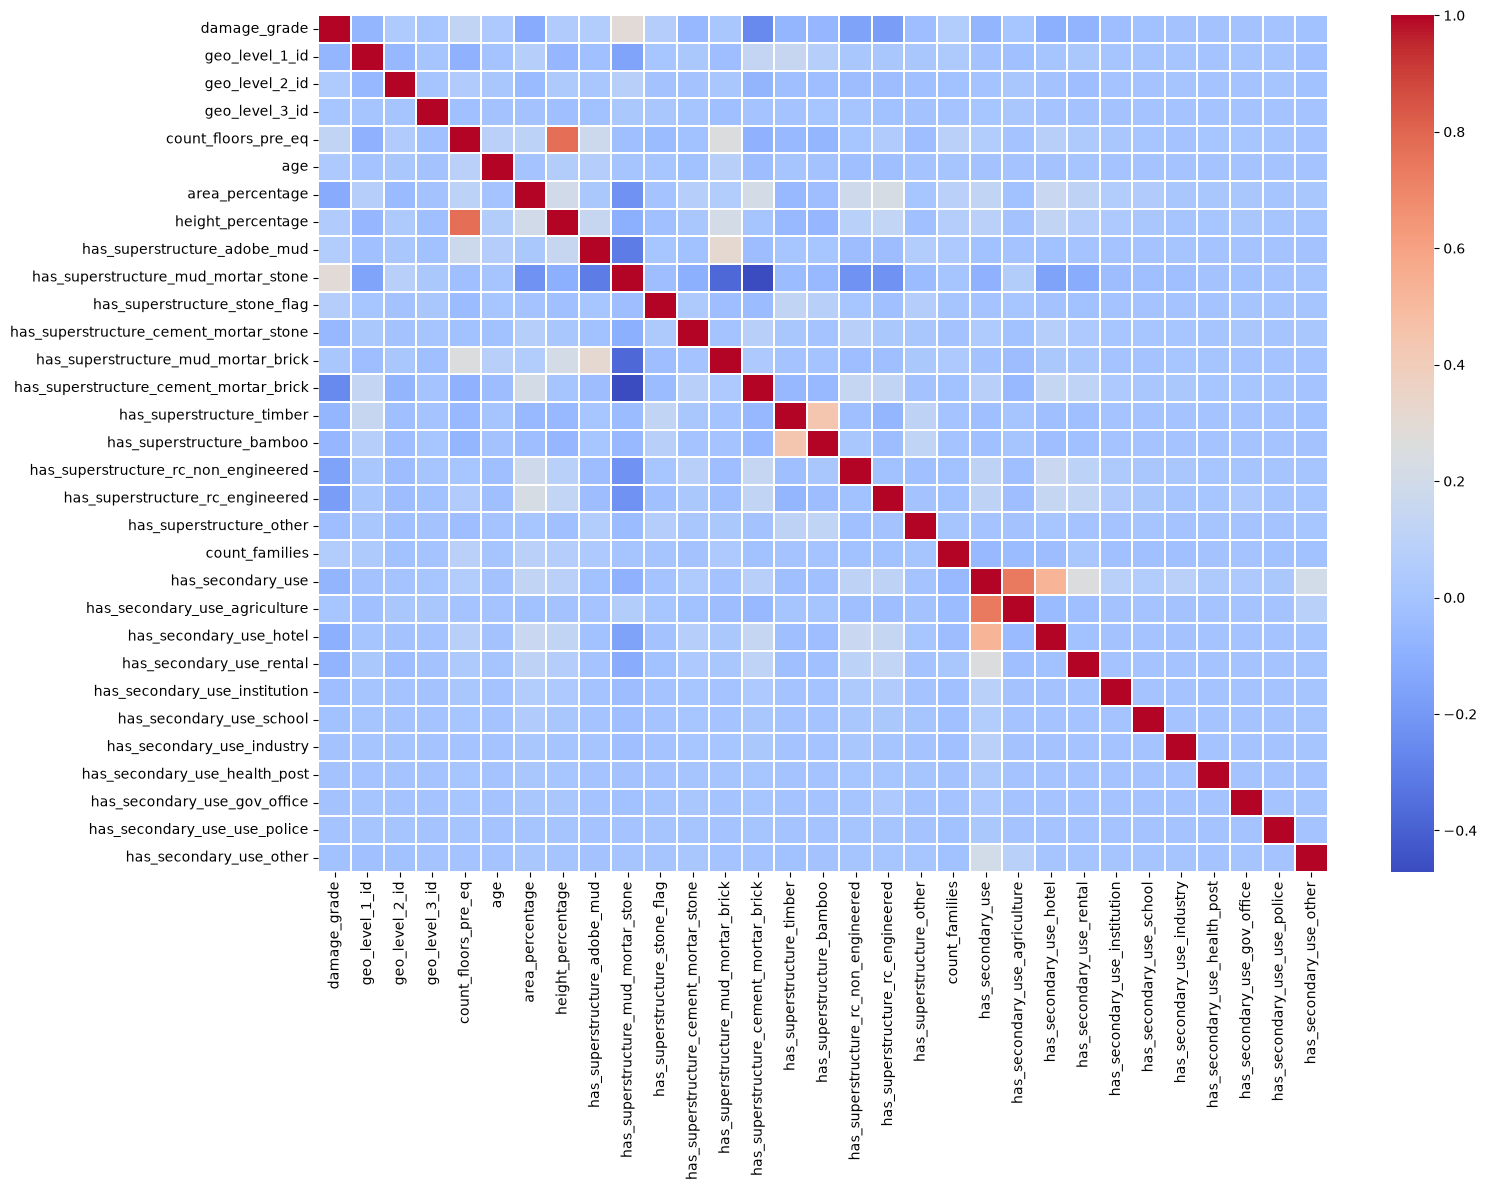

In [37]:
plt.figure(figsize=(16,12))

corr_matrix = numeric_cols.drop(columns = ['building_id']).corr()
# print(corr_matrix)
sns.heatmap(corr_matrix, annot=False, linewidths=0.3, cmap= 'coolwarm')
plt.tight_layout()
plt.show()

### Region 

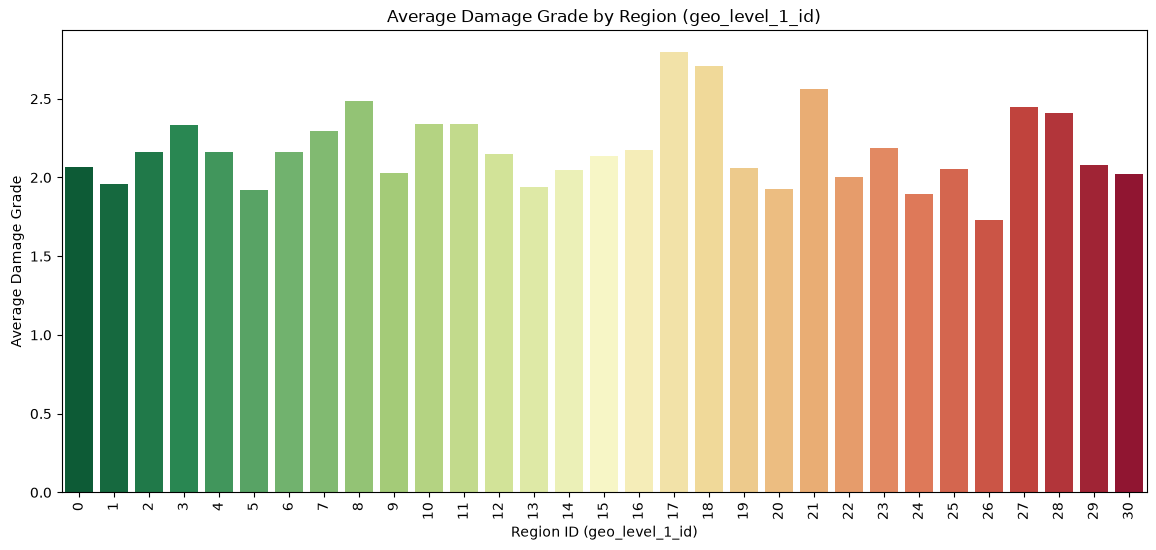

Top 5 most-damaged regions:
geo_level_1_id
17    2.794480
18    2.708373
21    2.563369
8     2.485273
27    2.446457
Name: damage_grade, dtype: float64

Top 5 least-damaged regions:
geo_level_1_id
13    1.937656
20    1.926464
5     1.919703
24    1.894656
26    1.730887
Name: damage_grade, dtype: float64


In [38]:
# Geospatial-style view: average damage grade by geo_level_1_id (broadest region)
region_damage = df.groupby("geo_level_1_id")["damage_grade"].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=region_damage.index, y=region_damage.values, palette="RdYlGn_r",
            hue=region_damage.index, legend=False)
plt.title("Average Damage Grade by Region (geo_level_1_id)")
plt.xlabel("Region ID (geo_level_1_id)")
plt.ylabel("Average Damage Grade")
plt.xticks(rotation=90)
plt.show()

print("Top 5 most-damaged regions:")
print(region_damage.head())
print("\nTop 5 least-damaged regions:")
print(region_damage.tail())

## has_secondary 

In [39]:
secondary_cols = [c for c in df.columns if c.startswith('has_secondary_use_') and c != "has_secondary_use"]

# c != "has_secondary_use" is used because one column is of no suffixe .



In [40]:
secondary_cols

['has_secondary_use_agriculture',
 'has_secondary_use_hotel',
 'has_secondary_use_rental',
 'has_secondary_use_institution',
 'has_secondary_use_school',
 'has_secondary_use_industry',
 'has_secondary_use_health_post',
 'has_secondary_use_gov_office',
 'has_secondary_use_use_police',
 'has_secondary_use_other']

____

## Feature Engineering

____

In [41]:
df['total_superstructure_materials'] = df[superstructure_cols].sum(axis=1)
df['total_secondary_use'] = df[secondary_cols].sum(axis=1)

print('new feature summary:')
print(df[['total_superstructure_materials', 'total_secondary_use']].describe().T)

new feature summary:
                                   count      mean       std  min  25%  50%  \
total_superstructure_materials  260601.0  1.460002  0.776945  1.0  1.0  1.0   
total_secondary_use             260601.0  0.114017  0.324488  0.0  0.0  0.0   

                                75%  max  
total_superstructure_materials  2.0  8.0  
total_secondary_use             0.0  2.0  


#### applying one-hot-encoding on categorical columns

In [42]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

encoded_array = ohe.fit_transform(df[categorical_columns])

encoded_col_name = ohe.get_feature_names_out(categorical_columns)

encoded_df = pd.DataFrame(encoded_array, columns = encoded_col_name, index = df.index)

df_encoded = df.drop(columns=categorical_columns)

df_encoded = pd.concat([df_encoded, encoded_df], axis = 1)

print('shape : ', df_encoded.shape)

shape :  (260601, 64)


In [43]:
df_encoded.head(5)

,building_id,damage_grade,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,total_superstructure_materials,total_secondary_use,land_surface_condition_o,land_surface_condition_t,foundation_type_i,foundation_type_r,foundation_type_u,foundation_type_w,roof_type_q,roof_type_x,ground_floor_type_m,ground_floor_type_v,ground_floor_type_x,ground_floor_type_z,other_floor_type_q,other_floor_type_s,other_floor_type_x,position_o,position_s,position_t,plan_configuration_c,plan_configuration_d,plan_configuration_f,plan_configuration_m,plan_configuration_n,plan_configuration_o,plan_configuration_q,plan_configuration_s,plan_configuration_u,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w
0,802906,3,6,487,12198,2,30,6,5,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,28830,2,8,900,2812,2,10,8,7,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,94947,3,21,363,8973,2,10,5,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,590882,2,22,418,10694,2,10,6,5,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,201944,3,11,131,1488,3,30,8,9,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [44]:

geo_cols = ["geo_level_1_id", "geo_level_2_id", "geo_level_3_id"]

for col in geo_cols:
    freq_map = df_encoded[col].value_counts(normalize=True)
    df_encoded[col + "_freq_enc"] = df_encoded[col].map(freq_map)


df_encoded = df_encoded.drop(columns=geo_cols)

print("Shape after geo frequency encoding:", df_encoded.shape)

df_encoded[[c for c in df_encoded.columns if "freq_enc" in c]].describe()

Shape after geo frequency encoding: (260601, 64)


,geo_level_1_id_freq_enc,geo_level_2_id_freq_enc,geo_level_3_id_freq_enc
count,260601.000000,260601.000000,260601.000000
mean,0.059988,0.002113,0.000235
std,0.027539,0.002511,0.000295
min,0.001017,0.000004,0.000004
25%,0.036869,0.000787,0.000084
50%,0.066063,0.001274,0.000150
75%,0.084723,0.002149,0.000269
max,0.093557,0.015495,0.002498


In [45]:
# 3. Multicollinearity check via VIF on the core continuous numeric features
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_check_cols = ["count_floors_pre_eq", "age", "area_percentage", "height_percentage",
                   "count_families", "total_superstructure_materials", "total_secondary_use"]

vif_data = df_encoded[vif_check_cols].copy()
vif_data = vif_data.fillna(0)

vif_results = pd.DataFrame()
vif_results["feature"] = vif_check_cols
vif_results["VIF"] = [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_check_cols))]
print(vif_results.sort_values("VIF", ascending=False))
# Rule of thumb: VIF > 10 signals problematic multicollinearity — flag but don't blindly drop,
# since tree-based models are not sensitive to this anyway.

                          feature        VIF
3               height_percentage  27.779986
0             count_floors_pre_eq  24.416498
2                 area_percentage   6.463925
4                  count_families   5.521424
5  total_superstructure_materials   4.002469
1                             age   2.411882
6             total_secondary_use   1.145267


### Defining X feature and Target Y

In [46]:
# from sklearn.preprocessing import LabelEncoder


x = df_encoded.drop(columns = ['building_id', 'damage_grade'])

y = df_encoded['damage_grade']


label_encoder  = LabelEncoder()
y_encoder = label_encoder.fit_transform(y)
print('original classes:', label_encoder.classes_)
print('Y Encoded classes:', np.unique(y_encoder))


original classes: [1 2 3]
Y Encoded classes: [0 1 2]


In [47]:
from sklearn.model_selection import train_test_split

x_train , x_test, y_train, y_test= train_test_split(x, y_encoder, test_size = 0.2, random_state= 42)

print('x_train shape : ',x_train.shape)
print('x_test shape : ',x_test.shape)

print('y_train shape : ',y_train.shape)
print('y_test shape : ',y_test.shape)


x_train shape :  (208480, 62)
x_test shape :  (52121, 62)
y_train shape :  (208480,)
y_test shape :  (52121,)


### Standard Scaler 

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scale = scaler.fit_transform(x_train)

x_test_scale = scaler.transform(x_test)

print('x_train_scale shape', x_train_scale.shape)
print('x_test_scale shape', x_test_scale.shape)


x_train_scale shape (208480, 62)
x_test_scale shape (52121, 62)


### Model Building

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight



model_lg = LogisticRegression(
    max_iter = 1000,
    solver="lbfgs",
    random_state=42,
    n_jobs=-1
)

model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss",
    sample_weight = compute_sample_weight('balanced', y_train)
)

In [50]:
from sklearn.metrics import accuracy_score

In [51]:
model_lg.fit(x_train_scale, y_train)

lg_model_train_pred = model_lg.predict(x_train_scale)
lg_model_test_pred = model_lg.predict(x_test_scale)
lg_model_test_pred_prob = model_lg.predict_proba(x_test_scale)

print('==== Logistic regression ====')
print('Train accuracy', accuracy_score(y_train, lg_model_train_pred))
print('Test accuracy', accuracy_score(y_test, lg_model_test_pred))
print('')
print('')
#########################################################

model_rf.fit(x_train, y_train)
rf_model_train_pred = model_rf.predict(x_train)
rf_model_test_pred = model_rf.predict(x_test)
rf_model_test_pred_prob = model_rf.predict_proba(x_test)



print('==== Random Forest ====')
print('Train accuracy', accuracy_score(y_train, rf_model_train_pred))
print('Test accuracy', accuracy_score(y_test, rf_model_test_pred))
print('')
print('')

#########################################################


model_xgb.fit(x_train, y_train)
xgb_model_train_pred = model_xgb.predict(x_train)
xgb_model_test_pred = model_xgb.predict(x_test)
xgb_model_test_pred_prob = model_xgb.predict_proba(x_test)



print('==== XGBoost ====')
print('Train accuracy', accuracy_score(y_train, xgb_model_train_pred))
print('Test accuracy', accuracy_score(y_test, xgb_model_test_pred))
print('')
print('')


==== Logistic regression ====
Train accuracy 0.5958077513430545
Test accuracy 0.592122177241419


==== Random Forest ====
Train accuracy 0.7514677666922487
Test accuracy 0.7078912530457973


==== XGBoost ====
Train accuracy 0.7459324635456639
Test accuracy 0.7292837819688801




### Model Evaluation
* Accuracy
* F1 - Score
* Confusion matrix
* ROC-Auc
* 5-fold cross-validation accuracy
* 

In [52]:
from sklearn.preprocessing import label_binarize

from sklearn.metrics import (accuracy_score, f1_score, classification_report, 
                            confusion_matrix, ConfusionMatrixDisplay, roc_auc_score)
from sklearn.model_selection import cross_val_score

### Logistic Regression Model Evaluation

=== Logistic Regression ===
              precision    recall  f1-score   support

           1       0.61      0.31      0.41      5170
           2       0.60      0.84      0.70     29487
           3       0.53      0.27      0.35     17464

    accuracy                           0.59     52121
   macro avg       0.58      0.47      0.49     52121
weighted avg       0.58      0.59      0.56     52121

F1 (macro): 0.4882984448227729
F1 (weighted): 0.5558323780198123
ROC-AUC (macro, OVR): 0.7300450123537464


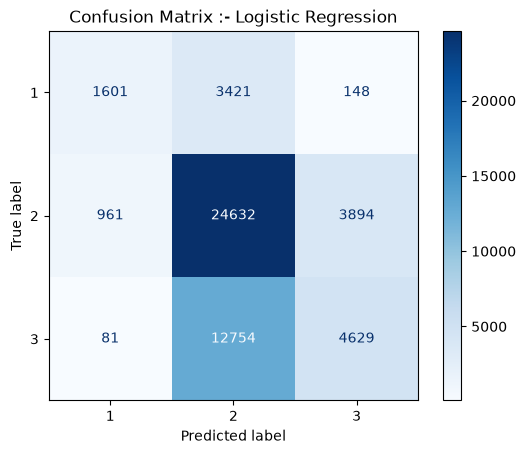

In [53]:
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])


print("=== Logistic Regression ===")
print(classification_report(y_test,lg_model_test_pred, target_names=[str(c) for c in label_encoder.classes_]))
lg_f1_macro = f1_score(y_test, lg_model_test_pred, average="macro")
lg_f1_weighted = f1_score(y_test, lg_model_test_pred, average="weighted")
lg_roc_auc = roc_auc_score(y_test_binarized, lg_model_test_pred_prob, average="macro", multi_class="ovr")
print("F1 (macro):", lg_f1_macro)
print("F1 (weighted):", lg_f1_weighted)
print("ROC-AUC (macro, OVR):", lg_roc_auc)

cm_log_reg = confusion_matrix(y_test, lg_model_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg, display_labels=label_encoder.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix :- Logistic Regression")
plt.show()

### Random Forest Model Evaluation

=== Random Forest ===
              precision    recall  f1-score   support

           1       0.73      0.39      0.51      5170
           2       0.70      0.86      0.77     29487
           3       0.73      0.55      0.62     17464

    accuracy                           0.71     52121
   macro avg       0.72      0.60      0.64     52121
weighted avg       0.71      0.71      0.70     52121

F1 (macro): 0.6354831751437822
F1 (weighted): 0.6957945945754133
ROC-AUC (macro, OVR): 0.8377897498691641


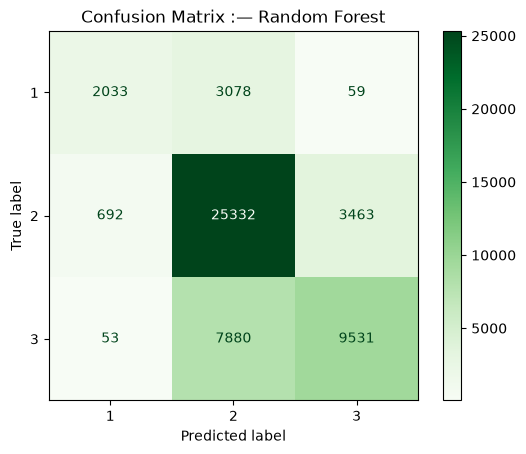

In [54]:
print("=== Random Forest ===")
print(classification_report(y_test, rf_model_test_pred, target_names=[str(c) for c in label_encoder.classes_]))

rf_f1_macro = f1_score(y_test, rf_model_test_pred, average="macro")
rf_f1_weighted = f1_score(y_test, rf_model_test_pred, average="weighted")
rf_roc_auc = roc_auc_score(y_test_binarized, rf_model_test_pred_prob, average="macro", multi_class="ovr")



print("F1 (macro):", rf_f1_macro)
print("F1 (weighted):", rf_f1_weighted)
print("ROC-AUC (macro, OVR):", rf_roc_auc)


cm_rf = confusion_matrix(y_test, rf_model_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=label_encoder.classes_)
disp.plot(cmap="Greens")



plt.title("Confusion Matrix :— Random Forest")
plt.show()

### XGBoost Model Evaluation

=== Xgboost ===
              precision    recall  f1-score   support

           1       0.73      0.46      0.57      5170
           2       0.72      0.86      0.78     29487
           3       0.75      0.59      0.66     17464

    accuracy                           0.73     52121
   macro avg       0.73      0.64      0.67     52121
weighted avg       0.73      0.73      0.72     52121

F1 (macro): 0.6705873925528995
F1 (weighted): 0.7211790922515812
ROC-AUC (macro, OVR): 0.8570599427325621


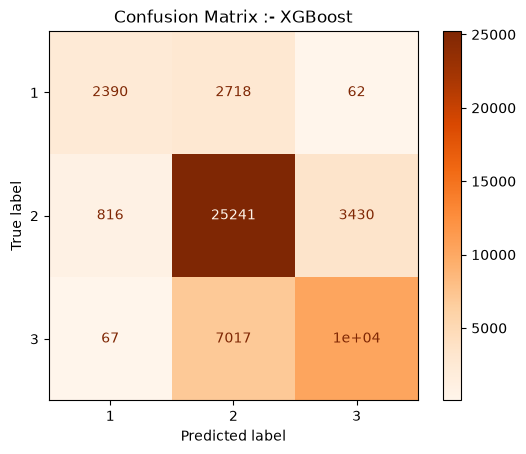

In [55]:
print("=== Xgboost ===")
print(classification_report(y_test, xgb_model_test_pred, target_names=[str(c) for c in label_encoder.classes_]))

xgb_f1_macro = f1_score(y_test, xgb_model_test_pred, average="macro")
xgb_f1_weighted = f1_score(y_test, xgb_model_test_pred, average="weighted")
xgb_roc_auc = roc_auc_score(y_test_binarized, xgb_model_test_pred_prob, average="macro", multi_class="ovr")



print("F1 (macro):", xgb_f1_macro)
print("F1 (weighted):", xgb_f1_weighted)
print("ROC-AUC (macro, OVR):", xgb_roc_auc)


cm_xgb = confusion_matrix(y_test, xgb_model_test_pred)
disp = ConfusionMatrixDisplay( confusion_matrix = cm_xgb, display_labels=label_encoder.classes_)
disp.plot( cmap= "Oranges")



plt.title("Confusion Matrix :- XGBoost")
plt.show()

In [56]:

sample_weights = compute_sample_weight('balanced', y_train)
model_xgb.fit(x_train, y_train, sample_weight=sample_weights)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

### Cross validation

In [57]:
from sklearn.model_selection import StratifiedKFold

In [59]:
# ----- Cross-validation (5-fold, stratified) on the full feature set -----

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


lg_cv_scores = cross_val_score(model_lg, x_train_scale, y_train, cv=cv_strategy, scoring="accuracy", n_jobs=-1)
rf_cv_scores = cross_val_score(model_rf, x_train, y_train, cv=cv_strategy, scoring="accuracy", n_jobs=-1)

print("Logistic Regression CV accuracy: %.4f (+/- %.4f)" % (lg_cv_scores.mean(), lg_cv_scores.std()))
print("Random Forest CV accuracy:       %.4f (+/- %.4f)" % (rf_cv_scores.mean(), rf_cv_scores.std()))


xgb_cv_scores = cross_val_score(model_xgb, x_train, y_train, cv=cv_strategy, scoring="accuracy", n_jobs=-1)
print("XGBoost CV accuracy:              %.4f (+/- %.4f)" % (xgb_cv_scores.mean(), xgb_cv_scores.std()))

Logistic Regression CV accuracy: 0.5955 (+/- 0.0012)
Random Forest CV accuracy:       0.7053 (+/- 0.0013)
XGBoost CV accuracy:              0.7277 (+/- 0.0016)


In [60]:
# ----- Final comparison table -----


comparison_rows = [
    ["Logistic Regression", accuracy_score(y_test, lg_model_test_pred), lg_f1_macro, lg_f1_weighted, lg_roc_auc, lg_cv_scores.mean()],
    ["Random Forest", accuracy_score(y_test, rf_model_test_pred), rf_f1_macro, rf_f1_weighted, rf_roc_auc, rf_cv_scores.mean()],
    ["XGBoost", accuracy_score(y_test, xgb_model_test_pred), xgb_f1_macro, xgb_f1_weighted, xgb_roc_auc, xgb_cv_scores.mean()]
]

model_comparison_df = pd.DataFrame(
    comparison_rows,
    columns=["Model", "Test Accuracy", "F1 (macro)", "F1 (weighted)", "ROC-AUC (macro OVR)", "CV Accuracy (mean)"]
)
model_comparison_df = model_comparison_df.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
model_comparison_df

,Model,Test Accuracy,F1 (macro),F1 (weighted),ROC-AUC (macro OVR),CV Accuracy (mean)
0,XGBoost,0.729284,0.670587,0.721179,0.857060,0.727662
1,Random Forest,0.707891,0.635483,0.695795,0.837790,0.705334
2,Logistic Regression,0.592122,0.488298,0.555832,0.730045,0.595491


### Hyperparameter Tuning

tuning :- Random Forest

In [62]:
from sklearn.model_selection import RandomizedSearchCV

In [63]:
# rf_param_dist ={
#     "n_estimators": [100, 200, 300, 400],
#     "max_depth": [10, 15, 20, 25, None],
#     "min_samples_split": [2, 5, 10],
#     "min_samples_leaf": [1, 2, 3, 5],
#     "max_features": ["sqrt", "log2"]

# }

# rf_random_search = RandomizedSearchCV(
#     estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
#     param_distributions=rf_param_dist,
#     n_iter=15,               # giving number of random combinations tried
#     cv=3,                    # trying with 3-fold CV to keep runtime reasonable at this data size
#     scoring="f1_macro",
#     random_state=42,
#     n_jobs=-1,
#     verbose=1
# )

# rf_random_search.fit(x_train, y_train)

# print("Best parameters found:", rf_random_search.best_params_)
# print("Best CV F1 (macro):", rf_random_search.best_score_)

#### Evaluating the tuned model 

In [64]:
# best_rf_model = rf_random_search.best_estimator_

# best_rf_test_preds = best_rf_model.predict(x_test)

# best_rf_test_proba = best_rf_model.predict_proba(x_test)



# print("=== Tuned Random Forest ===")
# print(classification_report(y_test, best_rf_test_preds, target_names=[str(c) for c in label_encoder.classes_]))




# tuned_accuracy = accuracy_score(y_test, best_rf_test_preds)
# tuned_f1_macro = f1_score(y_test, best_rf_test_preds, average="macro")
# tuned_roc_auc = roc_auc_score(y_test_binarized, best_rf_test_proba, average="macro", multi_class="ovr")




# print("Tuned test accuracy:", tuned_accuracy)
# print("Tuned F1 (macro):", tuned_f1_macro)
# print("Tuned ROC-AUC (macro OVR):", tuned_roc_auc)
# print("\nImprovement over baseline Random Forest accuracy:", tuned_accuracy - accuracy_score(y_test, rf_model_test_pred))

Tuning XGBoost model

In [65]:


xgb_param_distributions = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9],
    "min_child_weight": [1, 3, 5]
}

xgb_random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="multi:softprob", num_class=3,
        random_state=42, n_jobs=-1, eval_metric="mlogloss"
    ),
    param_distributions=xgb_param_distributions,
    n_iter=15,              # 15 random combinations try karega
    cv=3,                   # 3-fold cross-validation
    scoring="f1_macro",     # accuracy nahi — minority classes (grade 1,3) ko priority dene ke liye
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_random_search.fit(x_train, y_train)

print("Best parameters:", xgb_random_search.best_params_)
print("Best CV F1 (macro):", xgb_random_search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters: {'subsample': 0.8, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.2, 'colsample_bytree': 0.7}
Best CV F1 (macro): 0.6853225206245724


In [67]:
best_xgb_model = xgb_random_search.best_estimator_

best_xgb_test_preds = best_xgb_model.predict(x_test)

best_xgb_test_proba = best_xgb_model.predict_proba(x_test)



print("=== Tuned XGBOost ===")
print(classification_report(y_test, best_xgb_test_preds, target_names=[str(c) for c in label_encoder.classes_]))




tuned_accuracy_xgb = accuracy_score(y_test, best_xgb_test_preds)
tuned_f1_macro = f1_score(y_test, best_xgb_test_preds, average="macro")
tuned_roc_auc = roc_auc_score(
    label_binarize(y_test, classes =[0,1,2]),
    best_xgb_test_proba, average ='macro', multi_class ='ovr'
)




print("Tuned test accuracy:", tuned_accuracy_xgb)
print("Tuned F1 (macro):", tuned_f1_macro)
print("Tuned ROC-AUC (macro OVR):", tuned_roc_auc)
print("\nImprovement over baseline XGBoost F1 (macro):", tuned_f1_macro - tuned_accuracy_xgb)

=== Tuned XGBOost ===
              precision    recall  f1-score   support

           1       0.70      0.52      0.60      5170
           2       0.74      0.85      0.79     29487
           3       0.75      0.63      0.69     17464

    accuracy                           0.74     52121
   macro avg       0.73      0.67      0.69     52121
weighted avg       0.74      0.74      0.74     52121

Tuned test accuracy: 0.7428291859327334
Tuned F1 (macro): 0.6936533252243248
Tuned ROC-AUC (macro OVR): 0.8718071526120487

Improvement over baseline XGBoost F1 (macro): -0.049175860708408625


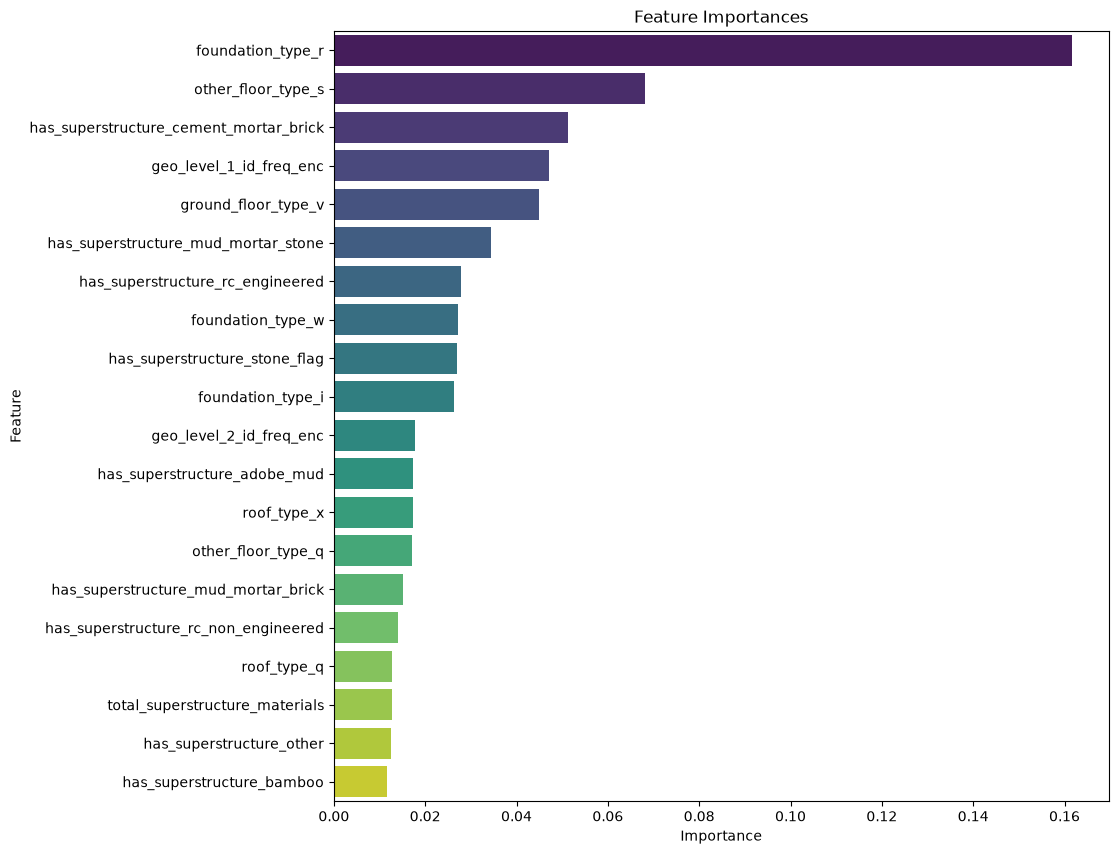

,feature,importance
32,foundation_type_r,0.161629
42,other_floor_type_s,0.068120
9,has_superstructure_cement_mortar_brick,0.051228
59,geo_level_1_id_freq_enc,0.047069
38,ground_floor_type_v,0.044891
5,has_superstructure_mud_mortar_stone,0.034511
13,has_superstructure_rc_engineered,0.027888
34,foundation_type_w,0.027272
6,has_superstructure_stone_flag,0.026883
31,foundation_type_i,0.026284


In [68]:
importances = best_xgb_model.feature_importances_

feature_importances_df = pd.DataFrame({
    "feature": x_train.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 10))
top_n = 20

sns.barplot(x="importance", y="feature", data=feature_importances_df.head(top_n),
            palette = 'viridis', hue='feature', legend=False)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importances")
plt.show()


feature_importances_df.head(10)

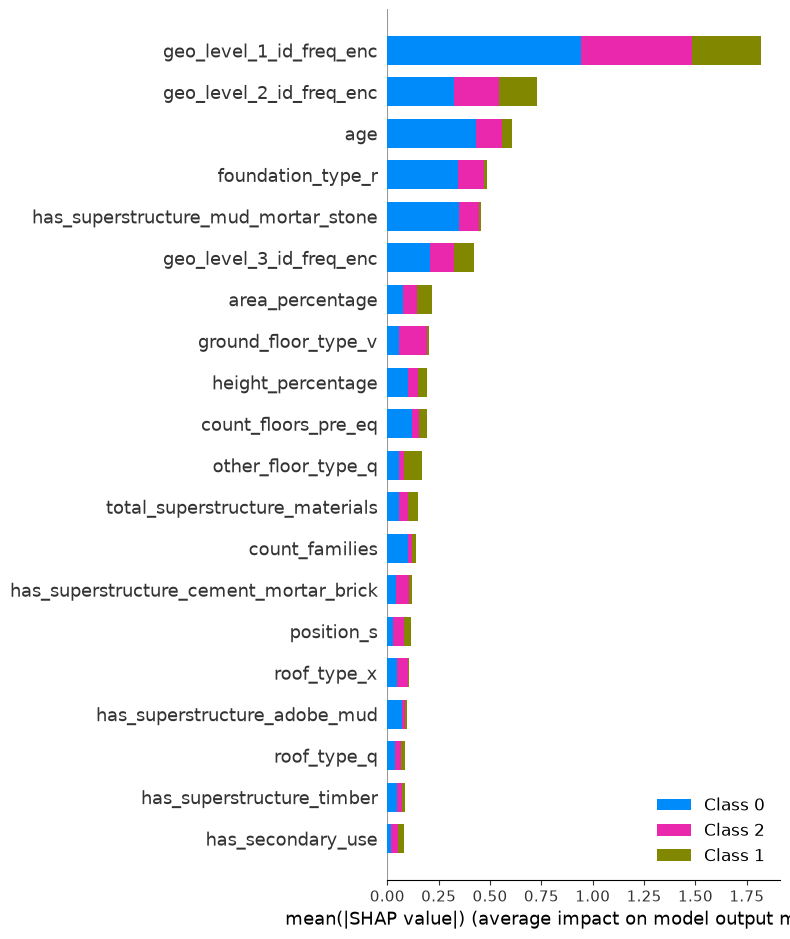

In [69]:
import shap


shape_sample = x_test.sample(n=500, random_state=42)
explainer = shap.TreeExplainer(best_xgb_model)
shap_values = explainer.shap_values(shape_sample)
plt.figure()

shap.summary_plot(shap_values, shape_sample, plot_type="bar")